<a href="https://colab.research.google.com/github/kyle-cech/FinalProject/blob/main/Eutrophication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd
import seaborn
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import os
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import LeaveOneOut
from sklearn import svm
import statsmodels.api as sm
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.tsa.stattools import adfuller

drive.mount('/content/drive') # create connection to Google Drive
filedir = '/content/drive/MyDrive/Eutrophication/' #file directory with all data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Retrieve data from folder and read in as pd dataframe
data = {}
files = os.listdir(filedir)
for f in files:
  path = filedir + f
  data[os.path.basename(path).split('.')[0]] = pd.read_csv(path)

In [3]:
cb = data.pop('Cyanobacteria') #save cyanobacteria data and remove from data
info = data.pop('reservoir_information') # remove reservoir info
year = data['surface_total_N']['year']
for i in data: #data cleanup
  df = data[i]
  if 'AgSE' not in df.columns:
    df = df.rename(columns={'agSE' : 'AgSE'})
  if 'For' not in df.columns and 'for' in df.columns:
    df = df.rename(columns={'for' : 'For'})
  if 'For' not in df.columns and 'forest' in df.columns:
    df = df.rename(columns={'forest' : 'For'})
  if 'Ag' not in df.columns:
    df = df.rename(columns={'ag' : 'Ag'})
  if 'ForSE' not in df.columns:
    df = df.rename(columns={'forSE' : 'ForSE'})
  if 'Agstrat' not in df.columns:
    df = df.rename(columns={'agstrat' : 'Agstrat'})
  if 'AgstratSE' not in df.columns:
    df = df.rename(columns={'agstratSE' : 'AgstratSE'})
  df = df.loc[:, 'CRR':'AgSE'] #restructure df
  df['year'] = year
  df = df.replace('na', pd.NA)
  data[i] = df.dropna()

In [4]:
#Make every nutrient its own dataframe with rows for the nutrient concentration, watershed name, and year
row = pd.DataFrame()
lis = []
for i in data:
  if not row.empty:
    lis.append(row)
    row = pd.DataFrame()
  for col in data[i]:
    year = data[i]['year']
    if col == 'year':
      continue
    x = data[i][col]
    y = [col] * len(year)
    df = pd.DataFrame({i : x, 'Watershed' : y, 'Year' : year})
    row = pd.concat([row, df])
lis

[   surface_total_N Watershed  Year
 1             0.35       CRR  1988
 22          0.8375       CRR  2009
 26         0.95355       CRR  2013
 27         1.71488       CRR  2014
 28     0.375809091       CRR  2015
 ..             ...       ...   ...
 27        0.420968      AgSE  2014
 28        0.348943      AgSE  2015
 29        0.401847      AgSE  2016
 30        0.717654      AgSE  2017
 31        0.374447      AgSE  2018
 
 [144 rows x 3 columns],
    surface_total_kjeldahl_N Watershed  Year
 0                       0.1       CRR  1987
 1                      0.15       CRR  1988
 22                   0.3175       CRR  2009
 26                  0.74875       CRR  2013
 27                     1.44       CRR  2014
 ..                      ...       ...   ...
 27                 0.179521      AgSE  2014
 28                 0.331658      AgSE  2015
 29                 0.113411      AgSE  2016
 30                  0.24773      AgSE  2017
 31                 0.123076      AgSE  2018
 

In [5]:
#Merge all data together to get all nutrient info together
df = pd.merge(lis[0], lis[1], how = 'outer')
c = 0
for i in lis:
  if c == 0 or c == 1:
    c += 1
    continue
  df = pd.merge(df, i, how = 'outer')

#Cleanup cyanobacteria data
cb = cb.set_axis([cb.loc[0]], axis='columns')
cb = cb.drop(cb.index[0])

In [6]:
#Add cyanobacteria to nutrient data to get final dataset
df['Cyanobacteria'] = pd.NA
for i in df.itertuples():
  shed = i.Watershed
  yr = str(i.Year)
  x = yr
  if shed in cb.columns and yr in cb['Row Labels'].values:
      idx = np.where(cb['Row Labels'] == yr)[0][0]
      val = cb.iloc[idx][shed]
      df.loc[i.Index, 'Cyanobacteria'] = val
cols = df.columns
surf = cols[:6]
surface = df[surf]
surface['Cyanobacteria'] = df['Cyanobacteria']
surface

<ipython-input-6-26d479851516>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  surface['Cyanobacteria'] = df['Cyanobacteria']


,surface_total_N,Watershed,Year,surface_total_kjeldahl_N,surface_TOC,surface_TP,Cyanobacteria
0,NaN,Ag,1987,0.514796,4.408163,35.581633,<NA>
1,2.77619,Ag,1988,0.566667,3.119048,51.285714,<NA>
2,NaN,Ag,1989,NaN,NaN,NaN,<NA>
3,NaN,Ag,1992,NaN,NaN,NaN,<NA>
4,NaN,Ag,1995,NaN,10.183333,NaN,<NA>
...,...,...,...,...,...,...,...
273,1.989647222,WFR,2014,1.941666667,5.763888889,98.01944444,543030.5264
274,1.771022222,WFR,2015,1.755555556,5.9,63.33333333,74179.04426
275,0.979272727,WFR,2016,0.939272727,8.619090909,84.61818182,311859.9957
276,1.386319048,WFR,2017,1.253333333,10.77619048,218.2380952,1938802.055


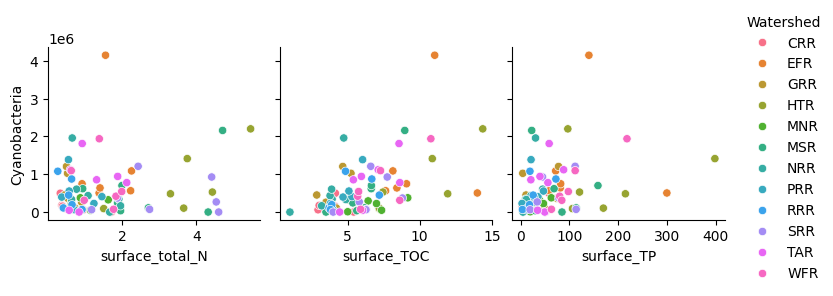

In [7]:
#Finish modifying and cleaning data, explore relationship with pairplot
surface_filt = surface.dropna()
surface_filt = surface_filt.loc[:, ['Year', 'Watershed', 'surface_total_N', 'surface_total_kjeldahl_N', 'surface_TOC', 'surface_TP', 'Cyanobacteria']]
columns_to_convert = ['surface_total_N', 'surface_total_kjeldahl_N', 'surface_TOC', 'surface_TP', 'Cyanobacteria', 'Year']
surface_filt[columns_to_convert] = surface_filt[columns_to_convert].apply(pd.to_numeric)
surface_filt = surface_filt.drop(surface_filt['Cyanobacteria'].idxmax())
sx = surface_filt[['surface_total_N', 'surface_TOC', 'surface_TP']]
sy = surface_filt[['Cyanobacteria']]
seaborn.pairplot(surface_filt, hue='Watershed', x_vars=sx, y_vars=sy)

In [8]:
q1 = surface_filt['Cyanobacteria'].quantile(0.25)
q2 = surface_filt['Cyanobacteria'].quantile(0.5)
q3 = surface_filt['Cyanobacteria'].quantile(0.75)
#make function to categorize based on quantile
def categorize(i):
  if i <= q1:
    return 1
  if i <= q2:
    return 2
  if i <= q3:
    return 3
  else:
    return 4
surface_filt['cb_quantile'] = surface_filt['Cyanobacteria'].apply(categorize) #categorize cyanobacteria concentration by their quantile

Tree Accuracy: 0.15789473684210525 Tree F1 Score: 0.13712121212121212


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Forest Accuracy: 0.05263157894736842 Forest F1 Score: 0.045454545454545456


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Logistic Accuracy: 0.21052631578947367 Logistic F1 Score: 0.18948412698412698
SVM Accuracy: 0.21052631578947367 SVM F1 Score: 0.1715686274509804
Gaussian Accuracy: 0.15789473684210525 Gaussian F1 Score: 0.14583333333333331


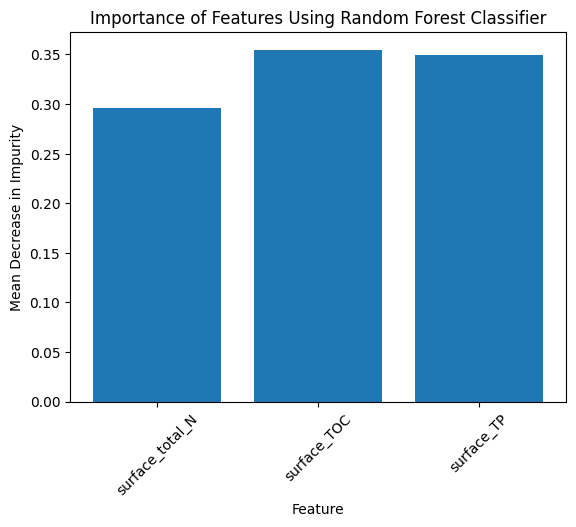

In [9]:
scaler = MinMaxScaler()
standard_sx = scaler.fit_transform(sx) #standardize data
trainx, testx, trainy, testy = train_test_split(standard_sx, surface_filt[['cb_quantile']]) #make train and test data

#Fit and predict decision tree classifier model
tree = DecisionTreeClassifier()
tree.fit(trainx, trainy) #fit decision tree
y_pred_tree = tree.predict(testx) #make predictions
acc = metrics.accuracy_score(testy, y_pred_tree)
f1 = metrics.f1_score(testy, y_pred_tree, average='macro')
print('Tree Accuracy:', acc, 'Tree F1 Score:', f1)

#Fit and predict random forest classifier model
forest = RandomForestClassifier()
forest.fit(trainx, trainy) #fit random forest
y_pred_forest = forest.predict(testx) #predict values for test data
acc = metrics.accuracy_score(testy, y_pred_forest)
f1 = metrics.f1_score(testy, y_pred_forest, average='macro')
print('Forest Accuracy:', acc, 'Forest F1 Score:', f1)
importance = forest.feature_importances_ #get feature importances
plt.bar(sx.columns, importance) #plot feature importances
plt.xticks(rotation = 45)
plt.xlabel('Feature')
plt.ylabel('Mean Decrease in Impurity')
plt.title('Importance of Features Using Random Forest Classifier')

#Fit and predict logistic regression model
log = LogisticRegression()
log.fit(trainx, trainy)
ypred = log.predict(testx)
acc = metrics.accuracy_score(testy, ypred)
f1 = metrics.f1_score(testy, ypred, average='macro')
print('Logistic Accuracy:', acc, 'Logistic F1 Score:', f1)

#Fit and predict SVM model
sv = svm.SVC(kernel='poly')
sv.fit(trainx, trainy)
ypred = sv.predict(testx)
acc = metrics.accuracy_score(testy, ypred)
f1 = metrics.f1_score(testy, ypred, average='macro')
print('SVM Accuracy:', acc, 'SVM F1 Score:', f1)

#Fit and predict GaussianNB model
gaussian = GaussianNB()
gaussian.fit(trainx, trainy)
ypred = gaussian.predict(testx)
acc = metrics.accuracy_score(testy, ypred)
f1 = metrics.f1_score(testy, ypred, average='macro')
print('Gaussian Accuracy:', acc, 'Gaussian F1 Score:', f1)

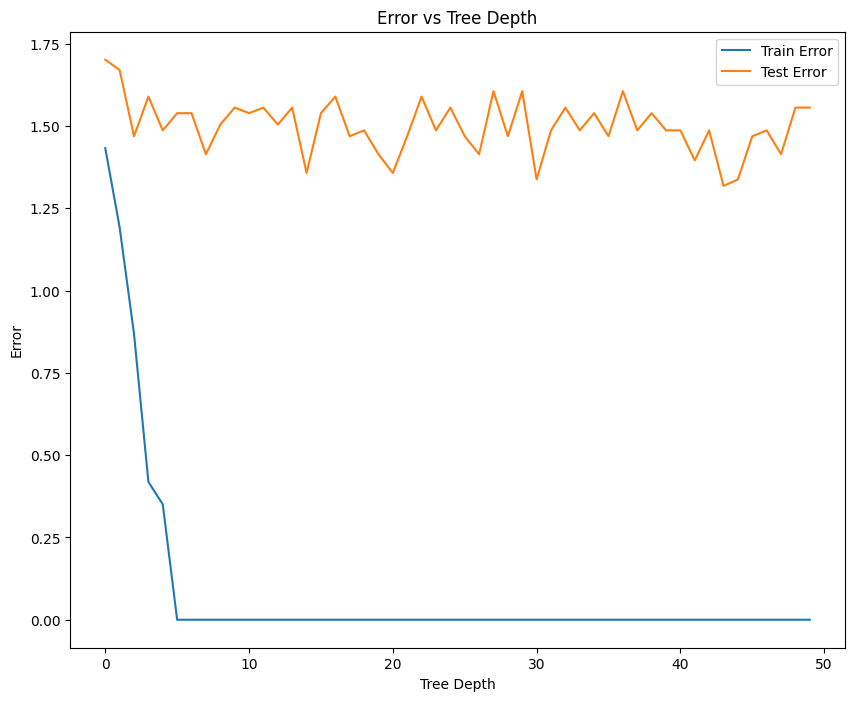

In [10]:
#Compare train and test error with max depth of random forest classifier
train_err = np.zeros(50)
test_err = np.zeros(50)

for i in range(0,50):
  mod = RandomForestClassifier(max_depth = i+1)
  mod.fit(trainx, np.ravel(trainy))
  ypred_train = mod.predict(trainx)
  ypred_test = mod.predict(testx)
  train_err[i] = np.sqrt(np.mean((np.ravel(trainy)-ypred_train)**2))
  test_err[i] = np.sqrt(np.mean((np.ravel(testy)-ypred_test)**2))

fig = plt.figure(figsize=(10,8))

plt.plot(train_err, label = 'Train Error')
plt.plot(test_err, label = 'Test Error')
plt.xlabel('Tree Depth')
plt.ylabel('Error')
plt.title('Error vs Tree Depth')
plt.legend()

In [11]:
#Do LOO-CV on gaussianNB, logistic, and random forest models to get best model
models = [GaussianNB(), LogisticRegression(), RandomForestClassifier(max_depth=3)]
for i in models:
  f1 = cross_val_score(i, standard_sx, surface_filt['cb_quantile'], cv=LeaveOneOut(), scoring = 'f1_macro')
  score = cross_val_score(i, standard_sx, surface_filt['cb_quantile'], cv=LeaveOneOut(), scoring = 'accuracy')
  print(i,':', 'F1-', f1.mean(), 'Accuracy-', score.mean())

GaussianNB() : F1- 0.2631578947368421 Accuracy- 0.2631578947368421
LogisticRegression() : F1- 0.17105263157894737 Accuracy- 0.17105263157894737
RandomForestClassifier(max_depth=3) : F1- 0.18421052631578946 Accuracy- 0.21052631578947367


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


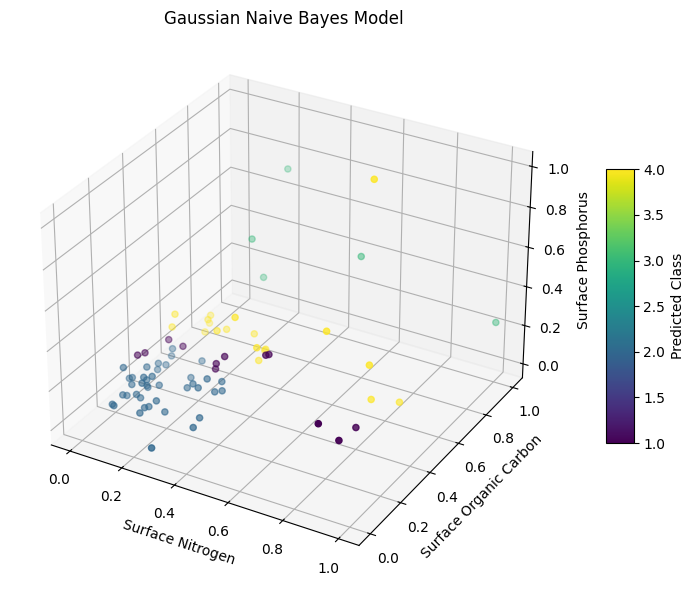

In [12]:
#Fit GaussianNB model and predict
nb = GaussianNB()
nb.fit(trainx, trainy)
ypred = nb.predict(standard_sx)
#Visualize predictions
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
scatter_plot = ax.scatter(standard_sx[:, 0], standard_sx[:, 1], standard_sx[:, 2], c=ypred)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel('Surface Nitrogen')
ax.set_ylabel('Surface Organic Carbon')
ax.set_zlabel('Surface Phosphorus', rotation = 90)
ax.set_title('Gaussian Naive Bayes Model')
cbar = fig.colorbar(scatter_plot, ax=ax, shrink=0.5, aspect=10)  # Adjust shrink and aspect as needed
cbar.set_label('Predicted Class')
plt.tight_layout()

In [91]:
#Use cyanobacteria data to get average of all watershed's cyanobacteria concentration by year
#Years that have less than a total of 10 samples will not be inclused
multiplied_avg = []
col = len(cb.columns) - 1
#cleanup df
# cb = cb.drop(27)
cb = cb.set_axis(np.ravel(cb['Row Labels']))
algae = cb.drop(columns=['Row Labels'], axis=1)
cols = algae.columns
algae[cols] = algae[cols].apply(pd.to_numeric, errors='coerce')
algae = algae.drop(columns=['Grand Total'], axis = 1)
for i in algae.to_numpy():
  t = 0
  c = 0
  for val in i:
    if np.isnan(val):
      continue
    else:
      t += 1
      c += float(val)

  if t >= 10:
    multiplied_avg.append((c / t) * col)
  else:
    multiplied_avg.append(pd.NA)

#make avg_alg series with this data
avg_alg = pd.Series(multiplied_avg, index = cb.index)
avg_alg = avg_alg.dropna()

#See if data is stationary
result = adfuller(avg_alg)
print('ADF statistic (%f)', result[0], 'pval (%f)', result[1])

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
ADF statistic (%f) 3.438399706965784 pval (%f) 1.0


<ipython-input-91-4a5102e0e2b5>:8: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  algae = cb.drop(columns=['Row Labels'], axis=1)
<ipython-input-91-4a5102e0e2b5>:11: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  algae = algae.drop(columns=['Grand Total'], axis = 1)


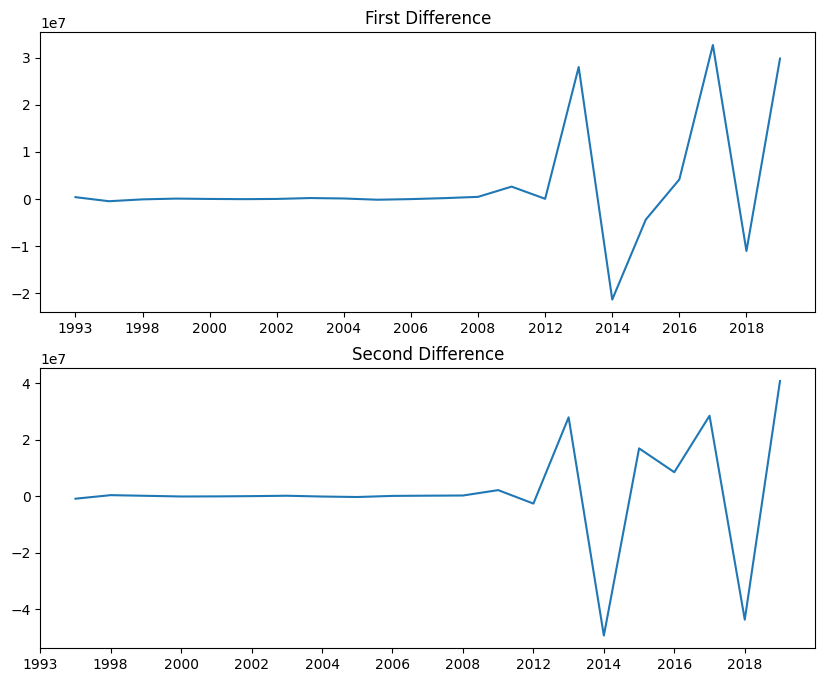

In [14]:
#Visualize autocorrelation and partial correlation to help decide ARIMA p, d, and q parameters
#See what kind of differencing should be done
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(avg_alg.diff())
ax[0].set_title('First Difference')
ax[0].set_xticks(np.arange(1, 22, 2))
ax[1].plot(avg_alg.diff().diff())
ax[1].set_title('Second Difference')
ax[1].set_xticks(np.arange(1, 22, 2))

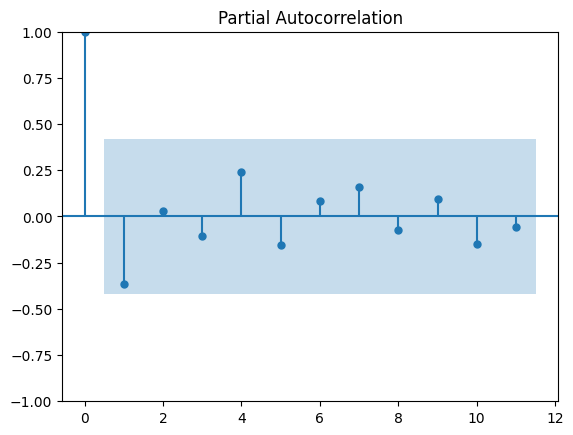

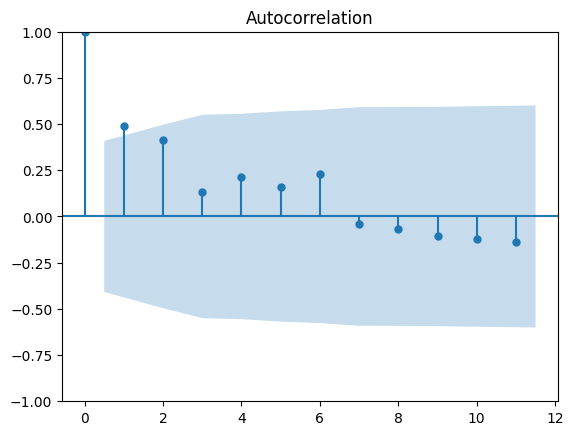

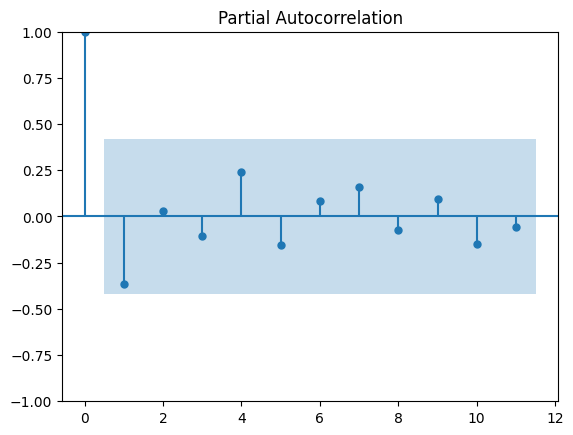

In [15]:
#Visualize autocorrelation and partial autocorrelation to help with ARIMA p, d, and q parameters
plot_acf(avg_alg.dropna())
plot_pacf(avg_alg.diff().dropna())

([<matplotlib.axis.XTick at 0x783dd979a210>,
 [Text(3, 0, '1992'),
  Text(6, 0, '1996'),
  Text(9, 0, '2000'),
  Text(12, 0, '2004'),
  Text(15, 0, '2008'),
  Text(18, 0, '2012'),
  Text(21, 0, '2016'),
  Text(24, 0, '2020'),
  Text(27, 0, '2024'),
  Text(30, 0, '2028')])

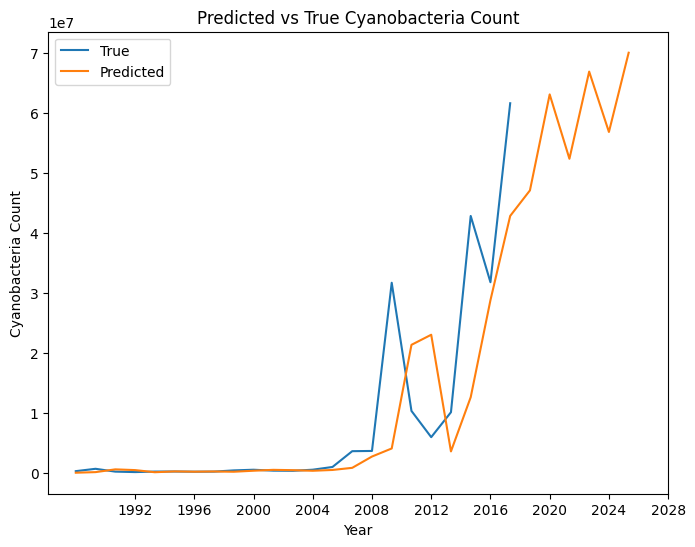

In [85]:
#Fit and predict with ARIMA model
avg_alg = pd.to_numeric(avg_alg, errors='coerce')
model = ARIMA(np.array(avg_alg), order=(2, 1, 3))
results_ARIMA = model.fit()

#Make forecast of cyanobacteria averages for next 10 years
forecast = results_ARIMA.forecast(steps=6)
predictions = np.append(results_ARIMA.predict(), forecast)
years = list(avg_alg.index)
other_years = np.arange(2019, 2025)
years.extend(other_years)
ts = pd.Series(predictions, index=years)

#Plot results
fig, ax = plt.subplots(figsize=(8, 6))
avg_alg.plot(ax=ax, label = 'True')
ts.plot(ax=ax, label = 'Predicted')
plt.legend()
plt.title('Predicted vs True Cyanobacteria Count')
plt.xlabel('Year')
plt.ylabel('Cyanobacteria Count')
plt.xticks([3, 6, 9, 12, 15, 18, 21, 24, 27, 30], np.arange(1992, 2029, 4))